<a href="https://colab.research.google.com/github/darpanrewani05/Linear_Regression/blob/main/practical_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Synthetic CSV created: malware_dataset_synthetic_5000.csv
Cleaned CSV saved: malware_dataset_cleaned.csv
Linear Regression Metrics -> RMSE: 0.2936, MAE: 0.2552, R2: -0.0027


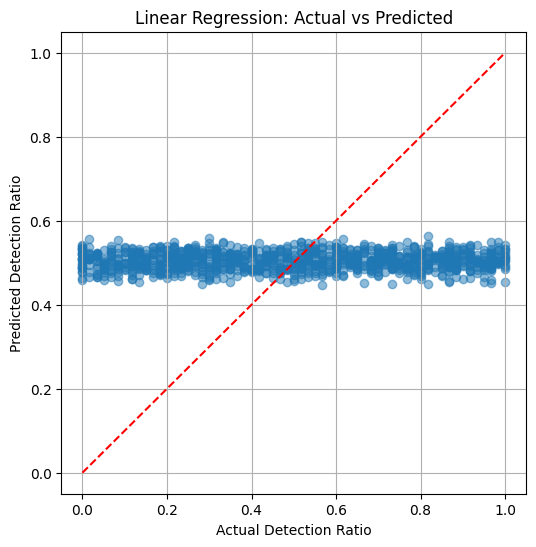

Saved predictions to regression_predictions.csv


In [6]:
# -------------------------
# STEP 1: IMPORT LIBRARIES
# -------------------------
import pandas as pd
import numpy as np
import random
import hashlib
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -------------------------
# STEP 2: GENERATE SYNTHETIC MALWARE DATASET
# -------------------------
random.seed(42)
N = 5000

families = ["Emotet","TrickBot","Ryuk","Zeus","AgentTesla","Dridex","Cerber","AZORult","Mirai","Unknown"]
file_types = ["PE32","PE32+","Script","PDF","DOC","EXE","DLL"]
av_sample_names = ["ESET","Kaspersky","Norton","McAfee","Bitdefender","Windows Defender","Avast","AVG","Sophos"]
domains = ["example.com","update-service.net","cdn-files.org","malicious-downloads.ru","tracker-site.info"]
ips = [f"192.0.2.{i}" for i in range(1,255)]

def rand_date(start, end):
    delta = end - start
    rnd = random.randint(0, delta.days)
    return (start + timedelta(days=rnd)).strftime("%Y-%m-%d")

start_date = datetime(2018,1,1)
end_date = datetime(2025,11,30)

rows = []
for i in range(1, N+1):
    fname = f"sample_{i:05d}." + random.choice(["exe","dll","bin","pdf","doc","js"])
    seed = f"{fname}-{random.random()}-{i}".encode("utf-8")
    md5 = hashlib.md5(seed).hexdigest()
    sha1 = hashlib.sha1(seed).hexdigest()
    sha256 = hashlib.sha256(seed).hexdigest()
    fsize = random.randint(1024,50000000)
    ftype = random.choice(file_types)
    first_seen = rand_date(start_date,end_date)
    last_seen = rand_date(datetime.strptime(first_seen,"%Y-%m-%d"),end_date)
    family = random.choice(families)
    label = random.choice(["malicious","benign","suspicious"])
    detections_total = 60
    detections_hit = random.randint(0,detections_total)
    detection_ratio = f"{detections_hit}/{detections_total}"
    avs = ";".join(random.sample(av_sample_names,k=random.randint(1,4)))
    ips_list = ";".join(random.sample(ips,k=random.randint(0,2)))
    doms = ";".join(random.sample(domains,k=random.randint(0,2)))
    entropy = round(random.uniform(3.0,8.0),3)
    rows.append({
        "id": i, "file_name": fname, "md5": md5, "sha1": sha1, "sha256": sha256,
        "file_size_bytes": fsize, "file_type": ftype, "first_seen": first_seen, "last_seen": last_seen,
        "family": family, "label": label, "detection_ratio": detection_ratio, "av_detections": avs,
        "c2_ips": ips_list, "domains": doms, "entropy": entropy, "pe_sections_count": random.randint(3,10),
        "packed": random.choice([True, False])
    })
df = pd.DataFrame(rows)
df.to_csv("malware_dataset_synthetic_5000.csv", index=False)
print("Synthetic CSV created: malware_dataset_synthetic_5000.csv")

# -------------------------
# STEP 3: DATA WRANGLING
# -------------------------
df["detection_ratio_float"] = df["detection_ratio"].apply(lambda x: int(x.split("/")[0])/60)
df["duration_days"] = (pd.to_datetime(df["last_seen"]) - pd.to_datetime(df["first_seen"])).dt.days
df["av_count"] = df["av_detections"].apply(lambda x: len(str(x).split(";")))
df["log_file_size_winsor"] = (df["file_size_bytes"].clip(1,50000000)).apply(lambda x: np.log(x))
df.fillna(df.median(numeric_only=True), inplace=True)
df.to_csv("malware_dataset_cleaned.csv", index=False)
print("Cleaned CSV saved: malware_dataset_cleaned.csv")

# -------------------------
# STEP 4: LINEAR REGRESSION
# -------------------------
TARGET = "detection_ratio_float"
numeric_features = ["entropy","pe_sections_count","av_count","duration_days","log_file_size_winsor"]
categorical_features = ["file_type","family","packed"]
X = df[numeric_features + categorical_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),("ohe", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([("num", numeric_transformer, numeric_features),
                                  ("cat", categorical_transformer, categorical_features)])

pipe = Pipeline([("pre", preprocessor),("lr", LinearRegression())])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression Metrics -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

# Plot predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'--', color='red')
plt.xlabel("Actual Detection Ratio")
plt.ylabel("Predicted Detection Ratio")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

# -------------------------
# STEP 5: SAVE PREDICTIONS
# -------------------------
df_test = X_test.copy()
df_test["actual_detection_ratio"] = y_test.values
df_test["pred_lr"] = y_pred
df_test.to_csv("regression_predictions.csv", index=False)
print("Saved predictions to regression_predictions.csv")
